# Neural Network Wine Quality Model

This notebook uses the preprocessed CSV/data files created in `Preprocessing/winequiality_tuning_dataset.ipynb`.

This program:

1. Loads train and test csv.
2. Separates attributes and labels.
3. Encodes labels for multiclass classification (`softmax`).
4. Imports neural network model.
5. Compiles model and declare:
    - Loss
    - Metric
    - Learning rate
6. Trains the model.
7. Plots train vs validation behavior (accuracy & loss).
8. Makes predictions for test.
9. Calculates metrics and show them on classification report.
10. Plots confusion Matrix.

## Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import sys
import os

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping


## 2. Load preprocessed datasets

In [4]:
# Use the files generated in the Preprocessing notebook.
# If your files are named differently, only change these paths.

train_df = pd.read_csv("../../Dataset/train/train.csv")
test_df = pd.read_csv("../../Dataset/test/test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()


Train shape: (12306, 12)
Test shape: (980, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,-1.476971,-0.676949,-0.777631,-0.396463,-0.876675,0.090254,0.273654,-1.015152,0.727373,-1.572934,0.811436,7
1,-0.773832,0.225769,-0.199185,-0.945154,-0.502390,0.265528,-0.762947,-1.633570,0.465637,-0.870325,1.954627,7
2,-0.539453,-0.075137,-0.116550,-0.376867,9.088661,1.492444,0.839073,0.248282,-0.450439,-0.079891,-0.903350,5
3,-0.656643,-0.576647,0.048721,-1.023539,-0.455604,-0.201869,-0.998539,-1.477303,-0.843043,2.203587,0.893092,6
4,-1.828540,0.225769,-1.438712,-0.435656,-0.783104,0.090254,-0.904302,-1.181394,0.727373,-1.133804,1.056405,8


## 2. Separate attributes and labels

In [5]:
X_train = train_df.drop("quality", axis=1).astype("float32")
y_train = train_df["quality"].astype("int")

X_test = test_df.drop("quality", axis=1).astype("float32")
y_test = test_df["quality"].astype("int")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTest class distribution:")
print(y_test.value_counts().sort_index())

print("\nUnique quality scores in training set:", y_train.unique())
print(y_train.value_counts().sort_index())

print(X_train.describe())
print(X_train.mean())
print(X_train.std())


X_train: (12306, 11)
y_train: (12306,)
X_test: (980, 11)
y_test: (980,)

Training class distribution:
quality
3    1758
4    1758
5    1758
6    1758
7    1758
8    1758
9    1758
Name: count, dtype: int64

Test class distribution:
quality
3      4
4     33
5    291
6    440
7    176
8     35
9      1
Name: count, dtype: int64

Unique quality scores in training set: [7 5 6 8 4 3 9]
quality
3    1758
4    1758
5    1758
6    1758
7    1758
8    1758
9    1758
Name: count, dtype: int64
       fixed acidity  volatile acidity   citric acid  residual sugar  \
count   12306.000000      12306.000000  12306.000000    12306.000000   
mean        0.249496          0.174656      0.009489       -0.133484   
std         1.174813          1.077914      0.883194        0.882684   
min        -3.586387         -1.980876     -2.760874       -1.141115   
25%        -0.474241         -0.454000     -0.457957       -0.878274   
50%         0.142313         -0.053075     -0.037342       -0.397552   
75%    

## 3. Encode labels

The wine quality labels are usually `3, 4, 5, 6, 7, 8, 9`.

For neural networks, we encode them as:

`3 → 0`, `4 → 1`, ..., `9 → 6`.


In [6]:
encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train).astype("int32")
y_test_encoded = encoder.transform(y_test).astype("int32")

num_classes = len(encoder.classes_)

print("Original classes:", encoder.classes_)
print("Number of classes:", num_classes)
print("Encoded labels example:", y_train_encoded[:10])


Original classes: [3 4 5 6 7 8 9]
Number of classes: 7
Encoded labels example: [4 4 2 3 5 3 3 2 3 4]


## 4. Import Neural network model

In [7]:
sys.path.append(os.path.abspath("../../"))

from models.neural_network_model import create_model 

model = create_model(num_classes)

model.summary()

C:\Users\mikeb\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 311 (1.21 KB)

 Trainable params: 311 (1.21 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile model

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


## 6. Train model

In [9]:
history = model.fit(
    X_train,
    y_train_encoded,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


Epoch 1/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1200 - loss: 2.0654 - val_accuracy: 0.0020 - val_loss: 2.2124
Epoch 2/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1421 - loss: 1.9550 - val_accuracy: 0.0024 - val_loss: 2.3196
Epoch 3/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2010 - loss: 1.8749 - val_accuracy: 0.0012 - val_loss: 2.4211
Epoch 4/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2421 - loss: 1.8130 - val_accuracy: 0.0012 - val_loss: 2.5175
Epoch 5/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2884 - loss: 1.7622 - val_accuracy: 0.0000e+00 - val_loss: 2.6105
Epoch 6/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3225 - loss: 1.7179 - val_accuracy: 0.0000e+00 - val_loss: 2.7070
Epoch 7/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3450 - loss: 1.6777 - val_accuracy: 0.0000e+00 - val_loss: 2.8091
Epoch 8/50
308/308 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3692 - loss: 1.6399 - val_

## 7. Train vs Validation behavior plots (accuracy & loss)

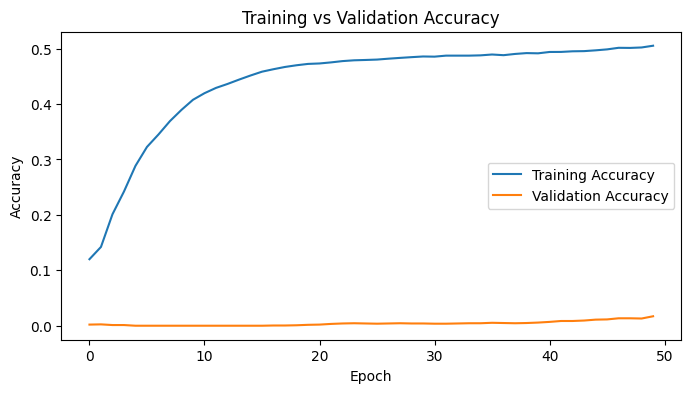

In [10]:
plt.figure(figsize=(8, 4))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


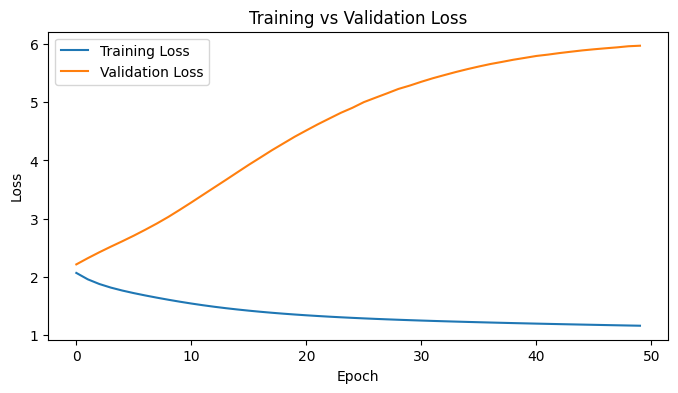

In [11]:
plt.figure(figsize=(8, 4))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


## 8. Predictions

In [12]:
y_train_pred_probs = model.predict(X_train)
y_test_pred_probs = model.predict(X_test)

print(y_test_pred_probs[:5])

y_train_pred = np.argmax(y_train_pred_probs, axis=1)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)


385/385 ━━━━━━━━━━━━━━━━━━━━ 0s 667us/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
[[2.1791550e-36 9.6735507e-23 9.9932289e-01 6.7714299e-04 1.5560024e-33
  0.0000000e+00 0.0000000e+00]
 [1.6137767e-14 1.4457982e-16 8.6690940e-02 9.1330898e-01 8.2597792e-32
  0.0000000e+00 0.0000000e+00]
 [9.2867361e-22 6.7449464e-14 7.4877006e-01 2.5122994e-01 1.4101466e-18
  1.6673448e-31 0.0000000e+00]
 [2.4289786e-05 4.0608468e-11 6.4195376e-03 9.9355620e-01 4.1276519e-19
  4.1348446e-31 0.0000000e+00]
 [4.5201138e-25 1.6276886e-15 9.7449511e-01 2.5504900e-02 1.1786665e-31
  0.0000000e+00 0.0000000e+00]]


## 9. Metrics calculation and classification report.

### Metrics function

In [13]:
def evaluate_model(y_true, y_pred, dataset_name):
    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"{dataset_name} Results")
    print("---------------------")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")


### Metrics results

In [14]:
evaluate_model(y_train_encoded, y_train_pred, "Training")
print()
evaluate_model(y_test_encoded, y_test_pred, "Test")


Training Results
---------------------
Accuracy : 0.4084
Precision: 0.3347
Recall   : 0.4084
F1 Score : 0.3580

Test Results
---------------------
Accuracy : 0.4082
Precision: 0.3481
Recall   : 0.4082
F1 Score : 0.3341


### Classification report

In [15]:
print(
    classification_report(
        y_test_encoded,
        y_test_pred,
        target_names=[str(label) for label in encoder.classes_],
        zero_division=0
    )
)


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        33
           5       0.37      0.89      0.52       291
           6       0.53      0.32      0.40       440
           7       0.00      0.00      0.00       176
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00         1

    accuracy                           0.41       980
   macro avg       0.13      0.17      0.13       980
weighted avg       0.35      0.41      0.33       980



## 10. Confusion matrix

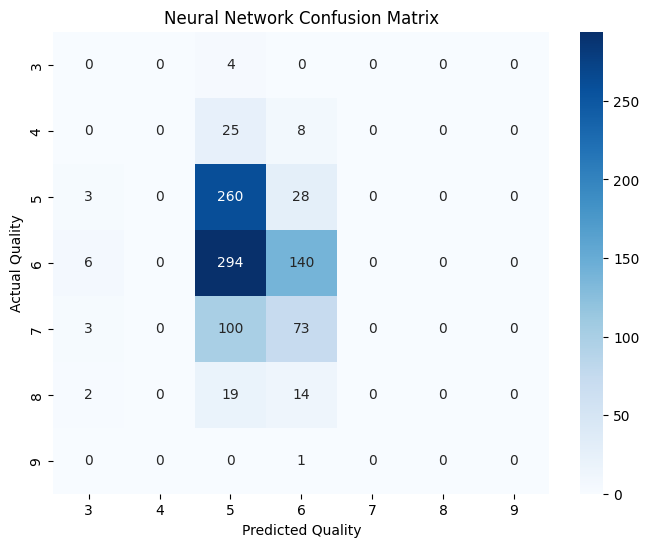

In [16]:
cm = confusion_matrix(
    y_test_encoded,
    y_test_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted Quality")
plt.ylabel("Actual Quality")

plt.show()
